<a href="https://colab.research.google.com/github/RPAlbuquerque/gsdm-spatial-ai/blob/main/MII_markdown.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Introduction

## 1.1 Motivation

Across cities worldwide, nearby locations often exhibit similar levels of mobility intensity while producing markedly different levels of economic activity. Busy commercial corridors and underperforming areas can exist side by side despite experiencing comparable volumes of human movement. These discrepancies suggest that mobility intensity alone is insufficient to explain the spatial conditions that enable sustained market activity.

Markets do not emerge solely from the presence of movement. Rather, they depend on spatial environments that allow individuals to repeatedly access locations, encounter services, and return over time. Such environments function as infrastructural systems that organize patterns of visitation, interaction, and economic exchange.

## 1.2 Conceptual Framework

This study conceptualizes *market infrastructure* as the latent behavioral structure embedded within mobility patterns. Instead of focusing exclusively on mobility volume, we examine how visitation behavior is organized across space through multiple signals, including visitor diversity, repeat visitation, dwell time, and temporal stability.

These signals collectively reflect the capacity of locations to support recurring access and sustained interactions. When combined, they reveal underlying infrastructural conditions that enable economic activity to persist in specific places while remaining weak or fragmented in others.

## 1.3 Research Question

Building on this perspective, we investigate whether market infrastructure can be empirically recovered from the behavioral covariance structure of mobility signals.

Specifically, we ask:

**Can a latent spatial infrastructure of markets be identified from the structure of human mobility behavior, and does this infrastructure explain spatial differences in economic activity?**

## 1.4 Analytical Strategy

To address this question, we develop a spatial analytical framework that combines behavioral mobility indicators, dimensionality reduction, spatial regime detection, and multiscale reconstruction.

First, we extract a latent Market Infrastructure Index (MII) from the covariance structure of mobility indicators using principal component analysis. We then analyze the spatial organization of this index across Brazil’s census tracts and identify territorially differentiated infrastructure regimes. Next, we evaluate how these regimes shape the relationship between mobility and economic intensity using nighttime light emissions as an external proxy.

Finally, we implement a mass-preserving downscaling procedure to reconstruct infrastructure patterns at a finer spatial resolution, revealing micro-scale fragmentation that remains hidden within aggregated administrative units.

# 2 Data

## 2.1 Data Provenance

The analytical dataset used in this study results from a structured preprocessing workflow designed to transform large-scale mobility traces into tract-level infrastructure indicators.

The workflow was implemented through four preprocessing pipelines.

**Pipeline A (Mobility)** transformed raw mobility traces into tract-level behavioral indicators capturing visitation intensity, visitor diversity, repeat visitation patterns, and temporal stability.

**Pipeline S (Spatial Integration)** spatially anchored these indicators to the official Brazilian census tract geometries defined by the Brazilian Institute of Geography and Statistics (IBGE) for the 2022 census.

**Pipeline V (Validation)** evaluated the internal consistency and robustness of the resulting mobility construct through statistical diagnostics and stability tests.

Finally, **Pipeline X (Spatial Structural Regime Modeling)** extracted the latent infrastructure structure embedded within mobility behavior and identified territorially differentiated infrastructure regimes.

Together, these pipelines produced the consolidated analytical dataset used in this notebook.

## 2.2 Raw Mobility Data

The mobility signals used in this study originate from a large-scale dataset of anonymized mobility traces aggregated across Brazil.

To facilitate distributed processing and storage, the dataset was partitioned into multiple compressed files. Each partition contains mobility observations that are later aggregated to the census tract level.

These data capture multiple behavioral dimensions of visitation activity, including visit frequency, visitor diversity, and visitation stability over time.

In [ ]:
import pandas as pd

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

mobility_file = "/ocean/projects/cis260037p/shared/data/mobility_data/mobility_merged.csv.gz"

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

mob = pd.read_csv(mobility_file, compression="gzip")

print("Dataset loaded successfully\n")

# ------------------------------------------------------------
# BASIC STRUCTURE
# ------------------------------------------------------------

total_rows = len(mob)
total_columns = len(mob.columns)
unique_sectors = mob["store_id"].nunique()

print("Total mobility records:", total_rows)
print("Total variables:", total_columns)
print("Census tracts with mobility data:", unique_sectors)

# ------------------------------------------------------------
# VARIABLE TABLE
# ------------------------------------------------------------

var_table = pd.DataFrame({
    "Variable": mob.columns,
    "Non-null observations": mob.notna().sum().values,
    "Missing observations": mob.isna().sum().values,
    "Data type": mob.dtypes.values
})

print("\nMobility dataset variables:\n")

display(var_table)

# ------------------------------------------------------------
# SUMMARY STATISTICS (KEY MOBILITY VARIABLES)
# ------------------------------------------------------------

key_vars = [
    "unique",
    "visits",
    "repeat_visitors",
    "new_visitors",
    "dwell_time_mins"
]

print("\nSummary statistics for key mobility indicators:\n")

display(mob[key_vars].describe().round(2))

Dataset loaded successfully

Total mobility records: 34949440
Total variables: 61
Census tracts with mobility data: 436868

Mobility dataset variables:



,Variable,Non-null observations,Missing observations,Data type
0,month_part,34949440,0,object
1,store_id,34949440,0,int64
2,demographics_gender,34949440,0,object
3,demographics_age_range,34949440,0,object
4,demographics_class,34949440,0,object
...,...,...,...,...
56,dow_7_h1,34949440,0,float64
57,dow_7_h2,34949440,0,float64
58,dow_7_h3,34949440,0,float64
59,dow_7_h4,34949440,0,float64



Summary statistics for key mobility indicators:



,unique,visits,repeat_visitors,new_visitors,dwell_time_mins
count,34949440.00,34949440.00,34949440.00,34949440.00,34078173.00
mean,2445.18,10296.74,1612.85,2444.46,57.23
std,8837.33,31905.81,5781.05,8837.53,31.57
min,0.00,0.00,0.00,0.00,1.00
25%,102.28,618.97,76.30,101.14,34.91
50%,504.96,2808.49,362.82,504.85,53.97
75%,1881.81,9408.59,1295.64,1881.80,74.28
max,1429843.67,9432496.36,1110024.66,1429843.67,1075.00


The merged mobility dataset contains **34,949,440 visitation records** describing human mobility behavior across Brazil.

These records capture multiple behavioral dimensions of visitation activity, including visitor diversity (`unique`), visit intensity (`visits`), repeat visitation patterns (`repeat_visitors`), and the inflow of new visitors (`new_visitors`). In addition, the dataset records the **average dwell time** of visitors within each location.

The summary statistics reveal substantial heterogeneity in visitation activity across space. While the median census tract receives approximately **2,808 visits**, highly active locations can exceed **9 million visits**, reflecting the presence of major commercial centers, transportation hubs, and dense urban areas.

Similarly, visitor diversity varies widely across locations. The median tract receives roughly **505 unique visitors**, whereas highly active tracts may receive more than **1.4 million unique visitors**.

The average dwell time across locations is approximately **57 minutes**, suggesting that many visits correspond to activities involving sustained interaction with places rather than short transient movements.

Together, these indicators capture multiple behavioral signals that reflect the capacity of locations to attract, retain, and repeatedly engage visitors. These signals form the empirical basis for constructing tract-level mobility indicators and recovering the latent infrastructure structure analyzed in this study.

## 2.3 Census Tract Geometries

Spatial units in the analysis correspond to the official census tracts defined by the Brazilian Institute of Geography and Statistics (IBGE) for the 2022 census geography.

Census tracts represent the smallest standardized territorial units used for national statistical reporting. These spatial units provide a consistent geographic framework for integrating behavioral mobility signals with spatial location.

The IBGE census tract dataset covers the entire national territory and contains detailed polygon geometries representing local spatial divisions across urban and rural areas.

In total, the dataset contains **472,780 census tracts**, providing complete geographic coverage of Brazil.

Census tracts loaded successfully

Total census tracts: 472780
Unique sector IDs: 468099
CRS: EPSG:4674

Columns available:
['CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO', 'AREA_KM2', 'CD_REGIAO', 'NM_REGIAO', 'CD_UF', 'NM_UF', 'CD_MUN', 'NM_MUN', 'CD_DIST', 'NM_DIST', 'CD_SUBDIST', 'NM_SUBDIST', 'CD_BAIRRO', 'NM_BAIRRO', 'CD_NU', 'NM_NU', 'CD_FCU', 'NM_FCU', 'CD_AGLOM', 'NM_AGLOM', 'CD_RGINT', 'NM_RGINT', 'CD_RGI', 'NM_RGI', 'CD_CONCURB', 'NM_CONCURB', 'geometry']


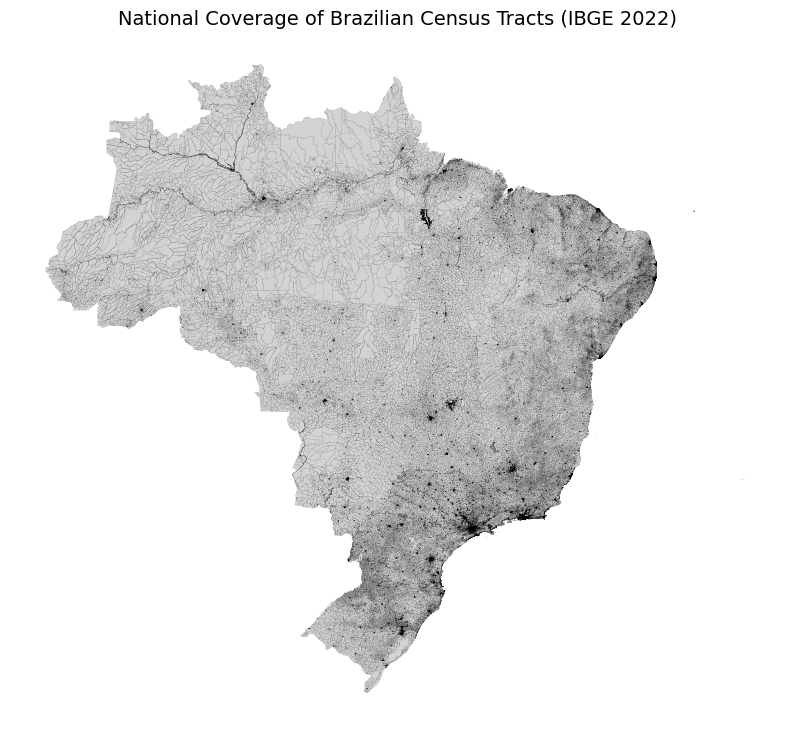

In [ ]:
import geopandas as gpd

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

shapefile_path = "/ocean/projects/cis260037p/shared/data/shapefiles/BR_setores_CD2022.gpkg"

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

tracts = gpd.read_file(shapefile_path)

print("Census tracts loaded successfully\n")

print("Total census tracts:", len(tracts))
print("Unique sector IDs:", tracts["CD_SETOR"].nunique())
print("CRS:", tracts.crs)

print("\nColumns available:")
print(tracts.columns.tolist())
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

tracts.plot(
    ax=ax,
    linewidth=0.05,
    color="lightgrey",
    edgecolor="black"
)

ax.set_axis_off()

ax.set_title(
    "National Coverage of Brazilian Census Tracts (IBGE 2022)",
    fontsize=14
)

plt.show()

The IBGE census tract dataset provides the spatial backbone of the analysis. With **472,780 census tracts**, the dataset ensures complete geographic coverage of Brazil, including both densely populated metropolitan areas and sparsely populated rural regions.

These geometries serve as the spatial units used to integrate mobility indicators, construct the Market Infrastructure Index (MII), and analyze spatial patterns of infrastructure across the national territory.

The nationwide spatial coverage ensures that the analysis captures both large-scale territorial patterns and localized infrastructure conditions across diverse geographic contexts.

## 2.4 Nighttime Lights Data

To evaluate the economic relevance of mobility-based infrastructure patterns, this study uses nighttime light emissions as an external proxy for local economic activity.

Nighttime luminosity data are derived from the **Visible Infrared Imaging Radiometer Suite (VIIRS)**, which measures stable nighttime illumination across the Earth's surface. Previous research has demonstrated that nighttime lights strongly correlate with economic activity, urbanization, and infrastructure development.

The dataset used in this study consists of multiple raster tiles covering global nighttime illumination patterns. These tiles provide high-resolution measurements of luminosity that can be spatially integrated with census tract geometries to evaluate the relationship between mobility infrastructure and economic intensity.

In [ ]:
import rasterio
import numpy as np
import os

nightlight_path = "/ocean/projects/cis260037p/shared/data/nightlights"

tiles = sorted([
    f for f in os.listdir(nightlight_path)
    if f.endswith(".tif")
])

print("Number of VIIRS tiles:", len(tiles))

# sample tile
sample_tile = os.path.join(nightlight_path, tiles[0])

with rasterio.open(sample_tile) as src:

    data = src.read(1)

    print("\nTile metadata:")
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)

    print("\nLuminosity statistics:")
    print("Min:", np.nanmin(data))
    print("Max:", np.nanmax(data))
    print("Mean:", np.nanmean(data))

Number of VIIRS tiles: 30

Tile metadata:
Shape: (5601, 17281)
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.00208333335, bottom=51.66458314665, right=-107.99791609064998, top=75.00208333335)

Luminosity statistics:
Min: -1.5
Max: 930.68317
Mean: 0.02460318


The VIIRS dataset consists of 30 raster tiles containing annual nighttime light intensity measurements.  
Each tile stores radiance values derived from satellite observations of stable nighttime illumination.

Luminosity values range from negative background-corrected values (resulting from noise filtering procedures) to very high intensities associated with dense urban and industrial areas.

Nighttime luminosity has been widely used as a proxy for economic activity, infrastructure development, and urbanization. In the analyses that follow, VIIRS luminosity data are used as an external benchmark to evaluate whether mobility-derived infrastructure patterns correspond to spatial variation in economic intensity.

## 2.5 Analytical Dataset

The final analytical dataset integrates mobility indicators, census tract geometries, and derived infrastructure metrics into a unified spatial database.

Each observation corresponds to a single census tract and contains behavioral mobility indicators, spatial attributes, and the derived **Market Infrastructure Index (MII)** used throughout the analysis.

The dataset preserves complete national geographic coverage while distinguishing between tracts with observed mobility activity and those without measurable visitation signals.

This consolidated dataset forms the empirical foundation for all subsequent analyses in this study.

The Market Infrastructure Index (MII) summarizes the latent behavioral structure embedded in mobility patterns across census tracts. The index is derived from the covariance structure of multiple mobility indicators through a dimensionality reduction procedure.

While the analytical dataset already includes the resulting index, the methodological procedure used to derive the MII is described in detail in Section 4.

In [ ]:
import geopandas as gpd

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

analysis_path = "/ocean/projects/cis260037p/shared/data/preprocessed_data/census_tracts_brazil_mobility_mii_clean.gpkg"

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

gdf = gpd.read_file(analysis_path)

print("Analytical dataset loaded successfully\n")

print("Total census tracts:", len(gdf))
print("Unique tract IDs:", gdf["ct_id"].nunique())
print("CRS:", gdf.crs)

print("\nColumns available:")
print(gdf.columns.tolist())
print("Census tracts with mobility data:", gdf["mii"].notna().sum())
print("Census tracts without mobility data:", gdf["mii"].isna().sum())
gdf["mii"].describe().round(3)

Analytical dataset loaded successfully

Total census tracts: 468099
Unique tract IDs: 468099
CRS: EPSG:4674

Columns available:
['ct_id', 'unique', 'visits', 'repeat_visitors', 'new_visitors', 'unique_q1', 'unique_q2', 'unique_q3', 'unique_q4', 'visits_q1', 'visits_q2', 'visits_q3', 'visits_q4', 'repeat_q1', 'repeat_q2', 'repeat_q3', 'repeat_q4', 'new_visitor_q1', 'new_visitor_q2', 'new_visitor_q3', 'new_visitor_q4', 'dwell_time_mins', 'unique_week_mean', 'unique_week_cv', 'visits_week_mean', 'visits_week_cv', 'unique_weeks_sum', 'unique_total_minus_weeks', 'visits_weeks_sum', 'visits_total_minus_weeks', 'log1p_visits_A4', 'log1p_unique_A4', 'log1p_repeat_visitors_A4', 'log1p_new_visitors_A4', 'stability_visits_week_cv_A4', 'stability_unique_week_cv_A4', 'z_dwell_time_mins', 'z_log1p_visits_A4', 'z_log1p_unique_A4', 'z_log1p_repeat_visitors_A4', 'z_log1p_new_visitors_A4', 'z_stability_visits_week_cv_A4', 'z_stability_unique_week_cv_A4', 'mii_zmean_A4', 'mii_pca1_A4', 'z_mii_zmean_A4', 

count    396948.000
mean         -0.027
std           0.875
min          -7.272
25%          -0.093
50%           0.205
75%           0.392
max           1.657
Name: mii, dtype: float64

In [ ]:
# ------------------------------------------------------------
# NORMALIZE MII TO [-1, 1]
# ------------------------------------------------------------

mii_min = gdf["mii"].min()
mii_max = gdf["mii"].max()

gdf["mii_norm"] = 2 * (gdf["mii"] - mii_min) / (mii_max - mii_min) - 1

print("Original MII range:")
print("Min:", gdf["mii"].min())
print("Max:", gdf["mii"].max())

print("\nNormalized MII range:")
print("Min:", gdf["mii_norm"].min())
print("Max:", gdf["mii_norm"].max())
gdf["mii_norm"].describe().round(3)
output_path = "/ocean/projects/cis260037p/shared/data/preprocessed_data/census_tracts_brazil_mii_normalized.gpkg"

gdf.to_file(output_path, driver="GPKG")

print("Dataset saved with normalized MII")

Original MII range:
Min: -7.271697051910064
Max: 1.6566794308497006

Normalized MII range:
Min: -1.0
Max: 1.0
Dataset saved with normalized MII


To facilitate interpretation and visualization of the Market Infrastructure Index (MII), the index was rescaled to a normalized range between **−1 and 1** using a min–max transformation.

This normalization preserves the relative ordering of census tracts while placing all values on a standardized scale. In the normalized index, values close to **−1** represent locations with relatively weak mobility infrastructure signals, whereas values close to **+1** indicate locations characterized by strong and stable visitation patterns.

Importantly, the original MII values derived from the principal component analysis are preserved in the dataset and remain the basis for statistical analyses. The normalized index is used primarily for visualization and interpretability in subsequent spatial analyses.

# 3 Behavioral Structure of Mobility

## 3.1 Mobility Indicators

Human mobility behavior can be characterized through multiple complementary signals capturing visitation intensity, visitor diversity, repeat visitation patterns, and temporal stability of visits.

The analytical dataset contains a set of indicators that collectively describe how individuals interact with places across space. These indicators include measures of total visits, unique visitors, repeat visitors, new visitors, average dwell time, and weekly stability of visitation patterns.

Rather than representing isolated measures of mobility activity, these variables capture different dimensions of the behavioral organization of visitation activity. Together, they provide the empirical basis for identifying latent infrastructure structures embedded within mobility patterns.

In [ ]:
mobility_vars = [
    "unique",
    "visits",
    "repeat_visitors",
    "new_visitors",
    "dwell_time_mins",
    "stability_unique_week_cv_A4",
    "stability_visits_week_cv_A4"
]

gdf[mobility_vars].describe().round(2)

,unique,visits,repeat_visitors,new_visitors,dwell_time_mins,stability_unique_week_cv_A4,stability_visits_week_cv_A4
count,396948.00,3.969480e+05,396948.00,396948.00,387858.00,387890.00,387890.00
mean,196144.03,8.255450e+05,129198.56,196089.80,57.58,-0.10,-0.13
std,493200.77,1.742929e+06,321212.26,493222.04,31.37,0.12,0.13
min,0.00,0.000000e+00,0.00,0.00,1.00,-2.00,-2.00
25%,20481.33,1.335012e+05,15677.06,20471.58,35.49,-0.10,-0.13
50%,70108.83,4.031793e+05,50724.37,70108.83,54.29,-0.07,-0.10
75%,191274.97,9.156881e+05,129325.51,191274.97,74.38,-0.05,-0.08
max,29887307.47,1.782099e+08,23202290.44,29887307.47,1075.00,0.00,0.00


The descriptive statistics highlight the substantial heterogeneity of mobility activity across census tracts. Visitation intensity varies by several orders of magnitude, with some locations receiving only a few visits while highly active tracts accumulate tens of millions of visits.

Similarly, visitor diversity follows a comparable distributional pattern, indicating that areas with high visitation intensity also tend to attract a large number of distinct visitors. This pattern suggests the presence of highly active mobility hubs such as dense urban centers, commercial districts, and transportation nodes.

Dwell time values indicate that visits typically involve sustained interaction with places, with an average dwell time of approximately one hour. This suggests that many recorded visits correspond to activities such as work, shopping, services, or leisure rather than short transient movements.

Finally, the stability indicators capture temporal consistency in visitation behavior. These variables describe how stable visitation patterns are across weeks, providing an additional dimension of behavioral structure beyond simple visitation volume.

Taken together, these indicators provide a multidimensional representation of human mobility behavior and serve as the empirical basis for identifying latent infrastructure structures embedded in mobility patterns.

## 3.2 Correlation Structure

The correlation matrix reveals strong associations among several mobility indicators. Measures capturing visitation intensity and visitor diversity are particularly strongly correlated, reflecting the fact that locations receiving many visits also tend to attract a diverse set of visitors.

Similarly, repeat visitation signals show substantial alignment with overall visitation levels, suggesting that many locations sustain recurring patterns of interaction rather than sporadic or isolated visits.

These correlation patterns indicate that multiple mobility indicators capture related aspects of an underlying behavioral structure governing visitation activity across space.

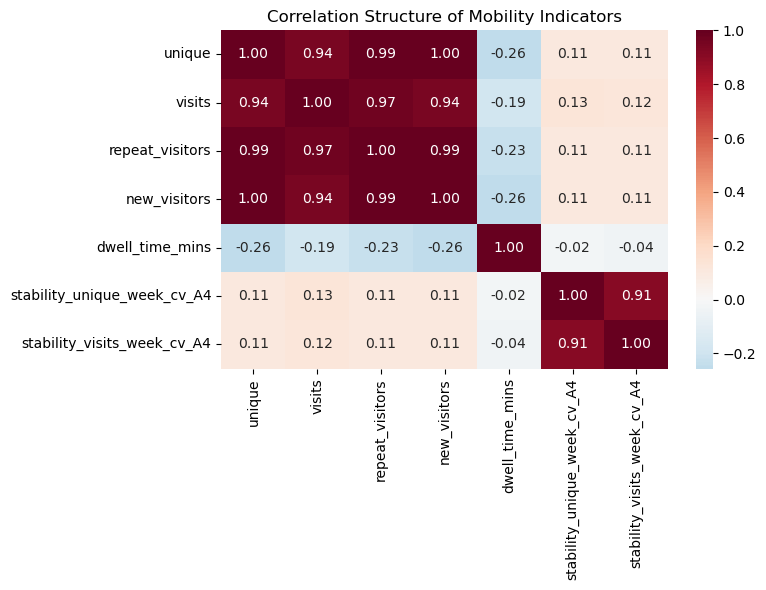

In [ ]:
corr = gdf[mobility_vars].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Structure of Mobility Indicators")

plt.tight_layout()

plt.show()

## 3.3 Evidence of Latent Behavioral Structure

The strong correlations observed among mobility indicators suggest that these variables capture related aspects of a common behavioral phenomenon.

Rather than representing independent signals, visitation intensity, visitor diversity, repeat visitation, and temporal stability appear to reflect a shared underlying structure governing how locations attract and sustain human mobility activity.

To evaluate whether such a latent structure exists, we examine the covariance structure of these indicators using principal component analysis (PCA). This approach allows us to determine whether a dominant dimension captures a substantial portion of the variation across mobility signals.

If a strong first component emerges, it would indicate the presence of an underlying infrastructural dimension organizing mobility behavior across locations.

Explained variance by component:
[0.578 0.265 0.133 0.014 0.01  0.    0.   ]


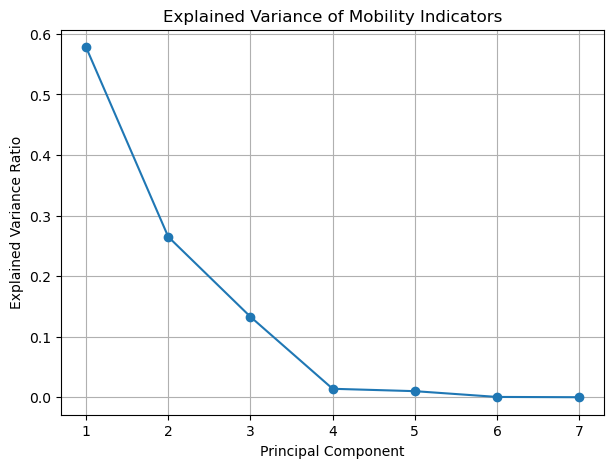

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# ------------------------------------------------------------
# SELECT VARIABLES
# ------------------------------------------------------------

X = gdf[mobility_vars].dropna()

# ------------------------------------------------------------
# STANDARDIZE VARIABLES
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# RUN PCA
# ------------------------------------------------------------

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance by component:")
print(np.round(explained_variance, 3))
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

components = range(1, len(explained_variance) + 1)

plt.plot(
    components,
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Explained Variance of Mobility Indicators")

plt.xticks(components)

plt.grid(True)

plt.show()

The principal component analysis reveals a highly structured covariance pattern among mobility indicators.

The first principal component alone explains approximately **58% of the total variance**, indicating a strong, dominant dimension that organizes mobility behavior across locations. When the first three components are considered jointly, they account for nearly all of the variance in the mobility system.

This result suggests that multiple visitation signals, including visitation intensity, visitor diversity, repeat-visitation patterns, and temporal stability, are not independent phenomena but rather manifestations of an underlying behavioral structure.

Such a pattern is consistent with the idea that some locations possess infrastructural properties that enable them to attract, sustain, and stabilize human mobility activity over time.

This dominant latent dimension provides the empirical foundation for constructing the **Market Infrastructure Index (MII)**, which summarizes the covariance structure of mobility indicators into a single spatially interpretable measure.

# 4 Construction of the Market Infrastructure Index

## 4.1 Indicator Standardization

To construct the Market Infrastructure Index (MII), mobility indicators must first be standardized to ensure comparability across variables with different measurement scales.

Standardization removes differences in magnitude and variance among indicators, allowing each variable to contribute proportionally to the covariance structure used in the dimensionality reduction procedure.

All mobility indicators were therefore transformed using **z-score normalization** prior to principal component analysis. This transformation centers each variable at zero and scales it by its standard deviation, ensuring that the extracted components reflect the structure of relationships among indicators rather than differences in measurement units.

In [ ]:
from sklearn.preprocessing import StandardScaler

X = gdf[mobility_vars].dropna()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Number of observations used in PCA:", X_scaled.shape[0])
print("Number of variables:", X_scaled.shape[1])

Number of observations used in PCA: 387779
Number of variables: 7


## 4.2 Principal Component Extraction

Principal component analysis (PCA) was applied to standardized mobility indicators to identify the dominant dimensions that organize visitation behavior across census tracts.

PCA decomposes the covariance structure of the indicators into orthogonal components ranked according to the proportion of variance they explain. The first component captures the strongest common variation among the indicators and therefore represents the dominant behavioral dimension underlying mobility activity.

Because this first component summarizes the shared structure of visitation intensity, visitor diversity, repeat visitation, and stability signals, it provides a natural candidate for constructing an aggregate measure of mobility-based market infrastructure.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

components = pca.components_

explained = pca.explained_variance_ratio_

print("Explained variance:")
print(explained)

Explained variance:
[5.77920270e-01 2.64832304e-01 1.32830240e-01 1.39370360e-02
 1.00086723e-02 4.71400325e-04 7.70319415e-08]


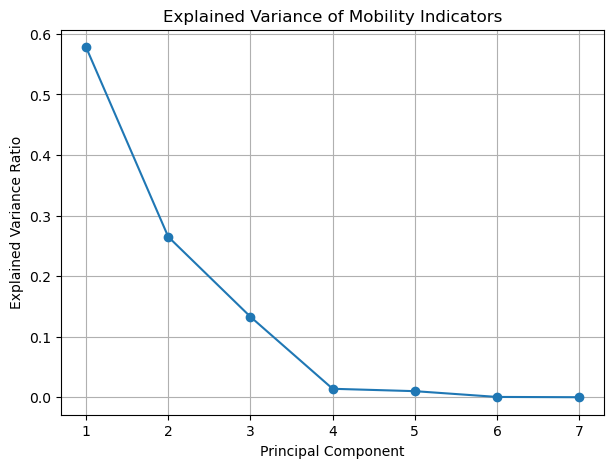

In [ ]:
import matplotlib.pyplot as plt

components = range(1, len(explained) + 1)

plt.figure(figsize=(7,5))

plt.plot(
    components,
    explained,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Explained Variance of Mobility Indicators")

plt.xticks(components)

plt.grid(True)

plt.show()

## 4.3 Component Loadings

To interpret the behavioral dimension extracted by principal component analysis, we examine the **component loadings** for the first principal component.

Loadings indicate how strongly each mobility indicator contributes to the latent dimension captured by the component. Variables with larger absolute loadings exert greater influence on the structure of the extracted component and therefore play a stronger role in defining the underlying behavioral pattern.

By analyzing these loadings, we can determine whether the dominant dimension reflects visitation intensity, visitor diversity, repeat-visitation dynamics, temporal stability, or a combination of these signals.

Examining the loadings, therefore, allows us to interpret the substantive meaning of the latent dimension that forms the basis of the **Market Infrastructure Index (MII)**.

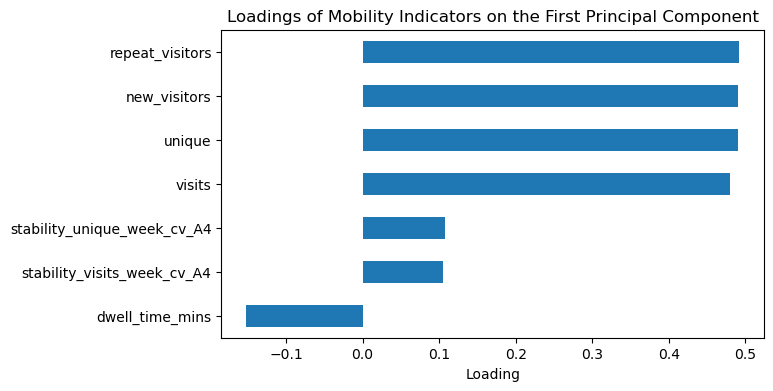

In [ ]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=mobility_vars,
    columns=[f"PC{i+1}" for i in range(len(mobility_vars))]
)

loadings

import matplotlib.pyplot as plt

loadings["PC1"].sort_values().plot(
    kind="barh",
    figsize=(7,4)
)

plt.title("Loadings of Mobility Indicators on the First Principal Component")

plt.xlabel("Loading")

plt.show()

The loadings of the first principal component indicate how each mobility indicator contributes to the dominant behavioral dimension extracted by the PCA.

Indicators capturing visitation intensity, visitor diversity, and repeat visitation exhibit strong positive contributions, indicating that locations scoring high on this component tend to attract many visitors and sustain recurring visitation patterns.

Temporal stability indicators also contribute to the component, reflecting the role of consistent visitation dynamics in supporting stable mobility activity across locations.

These patterns confirm that the first principal component captures a structural dimension associated with the capacity of places to sustain recurring patterns of human mobility activity.

## 4.4 Definition of the Market Infrastructure Index

The **Market Infrastructure Index (MII)** is defined as the first principal component extracted from the standardized mobility indicators.

Formally, the index is a weighted linear combination of the mobility indicators, with weights equal to the loadings of the first principal component.

Because the first component captures the dominant covariance structure among visitation signals, the resulting index summarizes the infrastructural capacity of locations to attract, sustain, and stabilize human mobility activity.

Higher index values correspond to locations with stronger, more stable visitation dynamics, while lower values indicate weaker or less organized mobility activity.

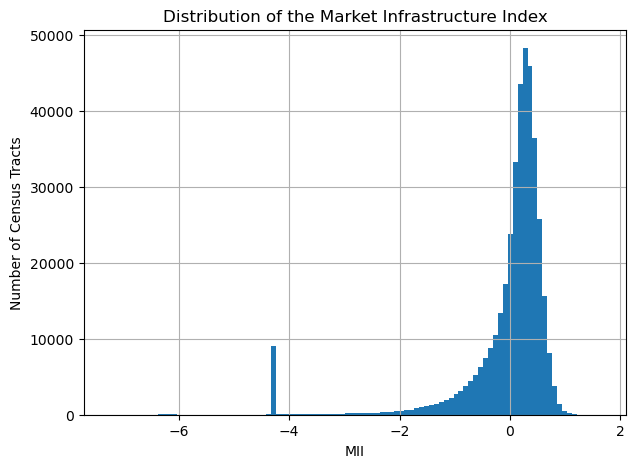

In [ ]:
plt.figure(figsize=(7,5))

gdf["mii"].hist(
    bins=100
)

plt.title("Distribution of the Market Infrastructure Index")

plt.xlabel("MII")

plt.ylabel("Number of Census Tracts")

plt.show()

## 2.5 Analytical Dataset

The final analytical dataset integrates the outputs of the preprocessing pipelines into a unified spatial database covering the entire national territory.

This dataset combines census tract geometries with mobility indicators and derived infrastructure metrics, ensuring that each observation corresponds to a single census tract with its associated behavioral and spatial attributes.

The dataset, therefore, contains the full set of mobility indicators used throughout the analysis as well as the **Market Infrastructure Index (MII)** derived from the covariance structure of visitation behavior.

Importantly, the dataset preserves complete national geographic coverage. While many census tracts exhibit measurable mobility activity, others contain little or no recorded visitation signals, allowing the dataset to represent both active and low-mobility areas across the territory.

The resulting geospatial dataset constitutes the empirical foundation for all subsequent analyses in this study.

In [ ]:
gdf = gpd.read_file(
    "/ocean/projects/cis260037p/shared/data/preprocessed_data/census_tracts_brazil_mobility_mii_clean.gpkg"
)

print("Analytical dataset loaded successfully\n")

print("Total census tracts:", len(gdf))
print("Unique tract IDs:", gdf["ct_id"].nunique())

print("\nCRS:", gdf.crs)

print("\nColumns available:")
print(list(gdf.columns))

Analytical dataset loaded successfully

Total census tracts: 468099
Unique tract IDs: 468099

CRS: EPSG:4674

Columns available:
['ct_id', 'unique', 'visits', 'repeat_visitors', 'new_visitors', 'unique_q1', 'unique_q2', 'unique_q3', 'unique_q4', 'visits_q1', 'visits_q2', 'visits_q3', 'visits_q4', 'repeat_q1', 'repeat_q2', 'repeat_q3', 'repeat_q4', 'new_visitor_q1', 'new_visitor_q2', 'new_visitor_q3', 'new_visitor_q4', 'dwell_time_mins', 'unique_week_mean', 'unique_week_cv', 'visits_week_mean', 'visits_week_cv', 'unique_weeks_sum', 'unique_total_minus_weeks', 'visits_weeks_sum', 'visits_total_minus_weeks', 'log1p_visits_A4', 'log1p_unique_A4', 'log1p_repeat_visitors_A4', 'log1p_new_visitors_A4', 'stability_visits_week_cv_A4', 'stability_unique_week_cv_A4', 'z_dwell_time_mins', 'z_log1p_visits_A4', 'z_log1p_unique_A4', 'z_log1p_repeat_visitors_A4', 'z_log1p_new_visitors_A4', 'z_stability_visits_week_cv_A4', 'z_stability_unique_week_cv_A4', 'mii_zmean_A4', 'mii_pca1_A4', 'z_mii_zmean_A4',

The analytical dataset contains **468,099 census tracts**, representing the complete spatial coverage of the national territory.

Each observation corresponds to a single census tract and contains a set of mobility indicators describing visitation intensity, visitor diversity, repeat visitation patterns, and temporal stability of mobility activity.

In addition to the raw behavioral indicators, the dataset includes derived variables used in the construction of the **Market Infrastructure Index (MII)**, which summarizes the covariance structure of mobility signals across locations.

This consolidated geospatial dataset therefore integrates behavioral mobility indicators, spatial attributes, and infrastructure metrics into a unified analytical base that serves as the empirical foundation for all subsequent analyses in this study.

# 5 Spatial Distribution of Market Infrastructure

## 5.1 National Spatial Distribution

Having constructed the Market Infrastructure Index (MII), we now examine how this infrastructure dimension is distributed across geographic space.

Because the index summarizes the covariance structure of mobility behavior across census tracts, its spatial distribution reveals where infrastructural conditions supporting recurring human mobility activity are strongest or weakest.

Mapping the index across the national territory allows us to visualize the spatial organization of mobility-based infrastructure and identify large-scale geographic patterns in the capacity of locations to sustain visitation activity.

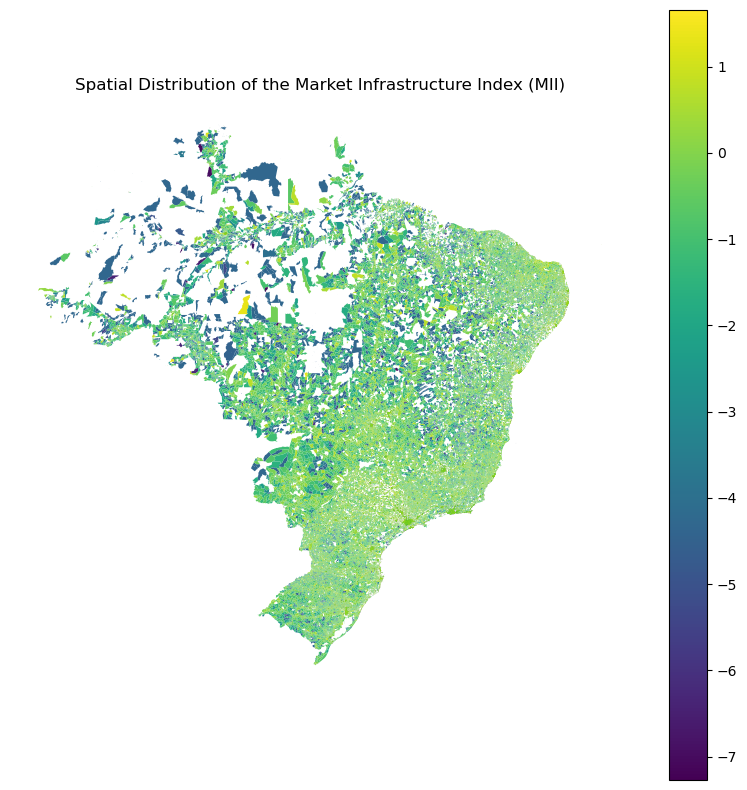

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    column="mii",
    cmap="viridis",
    linewidth=0,
    ax=ax,
    legend=True
)

ax.set_title("Spatial Distribution of the Market Infrastructure Index (MII)")

ax.set_axis_off()

plt.show()

## 5.2 Distribution Across the Territory

The spatial distribution of the Market Infrastructure Index reveals substantial geographic heterogeneity in the infrastructural conditions supporting mobility activity.

High-index regions tend to cluster around major metropolitan areas, transportation corridors, and economically active urban centers. These locations exhibit strong visitation intensity, diverse visitor flows, and stable patterns of recurring mobility.

In contrast, large portions of the national territory display relatively low index values, reflecting areas with limited visitation intensity or less structured mobility patterns. These regions often correspond to sparsely populated areas, environmentally protected regions, or locations with limited economic activity.

The resulting spatial pattern highlights the uneven territorial distribution of mobility-based infrastructure across the country.

# 6 Mobility Infrastructure Regimes

## 6.1 Identifying Infrastructure Regimes

While the Market Infrastructure Index provides a continuous measure of infrastructural conditions supporting mobility activity, locations may also organize into distinct structural regimes characterized by similar patterns of mobility behavior.

Identifying such regimes allows us to move beyond a purely continuous representation of infrastructure and instead detect clusters of locations sharing similar infrastructural characteristics.

To identify these regimes, we apply unsupervised clustering to the mobility infrastructure indicators, allowing census tracts with similar behavioral structures to be grouped together into distinct infrastructural regimes.

In [ ]:
from sklearn.cluster import KMeans

# variáveis usadas para clusterizar
X_cluster = gdf[mobility_vars].dropna()

# padronização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# modelo de clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_cluster_scaled)

# salvar clusters
gdf.loc[X_cluster.index, "infrastructure_regime"] = clusters

print("Clusters created successfully")

Clusters created successfully


## 6.2 Regime Characteristics

After identifying infrastructure regimes through unsupervised clustering, we examine the behavioral characteristics associated with each regime.

To interpret the meaning of the clusters, we compute the average values of the mobility indicators within each regime. These averages allow us to understand how visitation intensity, visitor diversity, repeat visitation, dwell time, and temporal stability differ across infrastructural environments.

Comparing these regime-level averages provides insight into the structural differences between mobility environments and helps reveal how distinct types of locations organize human mobility activity across space.

In [ ]:
gdf.groupby("infrastructure_regime")[mobility_vars].mean().round(2)

,unique,visits,repeat_visitors,new_visitors,dwell_time_mins,stability_unique_week_cv_A4,stability_visits_week_cv_A4
infrastructure_regime,,,,,,,
0.0,119184.11,577347.39,80656.50,119141.34,59.54,-0.08,-0.12
1.0,6788873.90,22594184.10,4455320.13,6788873.90,19.51,-0.06,-0.09
2.0,2837.15,13088.19,1915.59,2047.37,56.81,-0.69,-0.76
3.0,1235640.58,4296439.64,782240.49,1235640.58,29.81,-0.06,-0.09


The regime-level averages reveal clear structural differences in mobility behavior across census tracts.

One regime exhibits extremely high visitation intensity and very large visitor numbers, indicating locations that serve as major mobility hubs. These areas concentrate high visitor flows while exhibiting relatively short dwell times, suggesting environments characterized by rapid circulation, such as major urban centers, transportation nodes, and highly active commercial districts.

A second regime shows very high but less extreme visitation levels combined with moderate dwell times, representing large urban environments where mobility activity is substantial but less concentrated than in the most intense hubs.

Another regime exhibits intermediate visitation intensity alongside longer dwell times. These locations likely correspond to urban neighborhoods and local service areas where individuals spend more time interacting with specific places.

Finally, a low-intensity regime emerges in which visitation levels are very limited and mobility patterns are comparatively unstable. These areas likely correspond to sparsely populated regions, rural environments, or locations with limited economic activity.

Together, these regimes highlight the structural diversity of mobility-based infrastructure across the national territory.

## 6.3 Spatial Distribution of Infrastructure Regimes

Having characterized the behavioral properties of each infrastructure regime, we now examine how these regimes are distributed across geographic space.

Mapping the regimes allows us to observe how different mobility environments are organized across the national territory and whether specific infrastructural configurations tend to cluster spatially.

This spatial perspective provides insight into the territorial structure of mobility infrastructure and reveals how different types of mobility environments are distributed between dense urban regions and less active areas.

Dataset loaded
Rows: 472780
Columns: Index(['ct_id', 'regime_2D_full', 'geometry'], dtype='object')
Defaulting to user installation because normal site-packages is not writeable


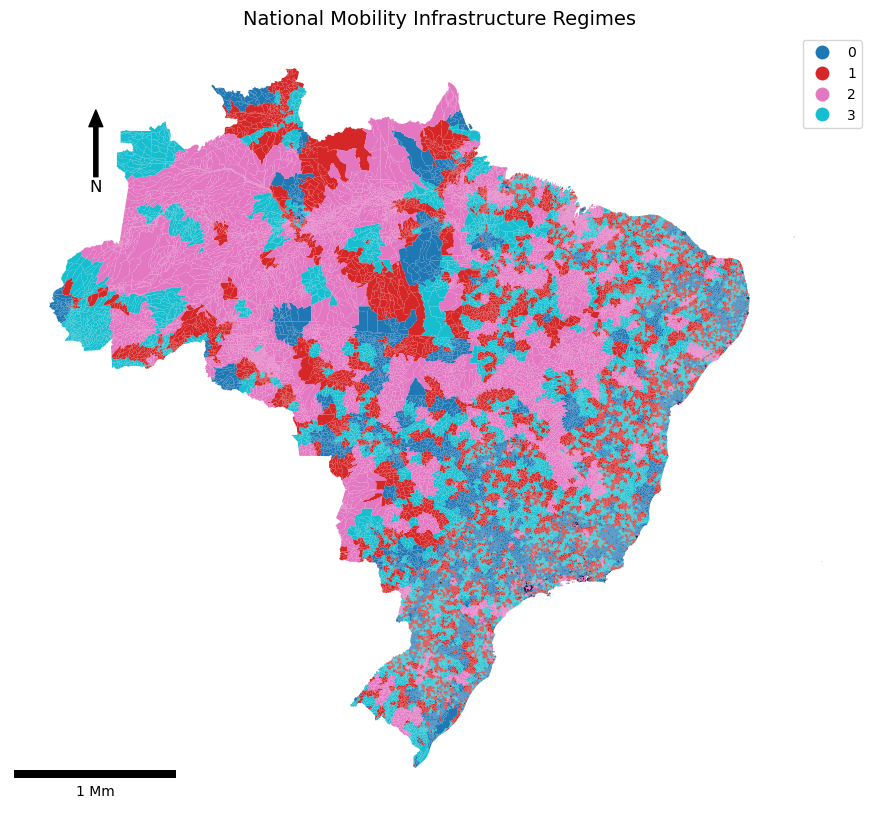

In [ ]:
import geopandas as gpd

regimes = gpd.read_file(
    "/ocean/projects/cis260037p/shared/data/regimes_shape/X8b_national_regime.gpkg"
)

print("Dataset loaded")
print("Rows:", len(regimes))
print("Columns:", regimes.columns)

def add_north_arrow(ax, size=0.1):
    x, y = 0.1, 0.9

    ax.annotate(
        'N',
        xy=(x, y),
        xytext=(x, y-size),
        arrowprops=dict(facecolor='black', width=3, headwidth=10),
        ha='center',
        va='center',
        fontsize=12,
        xycoords=ax.transAxes
    )

!pip install matplotlib-scalebar

import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

fig, ax = plt.subplots(figsize=(12,10))

regimes.plot(
    column="regime_2D_full",
    categorical=True,
    cmap="tab10",
    linewidth=0,
    ax=ax,
    legend=True
)

ax.set_title("National Mobility Infrastructure Regimes", fontsize=14)

ax.set_axis_off()

# north arrow
add_north_arrow(ax)

# scale bar
scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    box_alpha=0
)

ax.add_artist(scalebar)

plt.show()

## Spatial Distribution of Infrastructure Regimes

The national propagation of structural mobility regimes reveals clear territorial organization of mobility-based infrastructure across Brazil.

Highly developed infrastructure regimes cluster around major metropolitan areas and economically active urban corridors, where visitation intensity and mobility flows are particularly strong.

Intermediate regimes appear around regional cities and secondary economic centers, reflecting areas with moderate but stable mobility activity.

Low-intensity regimes dominate large portions of sparsely populated regions, indicating locations where visitation activity is limited and mobility patterns are comparatively weak.

Together, these spatial patterns demonstrate that mobility infrastructure forms territorially structured environments rather than a uniform geography of movement.

# 7 Economic Differentiation Across Infrastructure Regimes

## 7.1 Economic Proxy: Nighttime Lights

To examine whether mobility infrastructure regimes correspond to distinct levels of economic activity, we use nighttime satellite luminosity as an external proxy for local economic intensity.

Nighttime lights data derived from the Visible Infrared Imaging Radiometer Suite (VIIRS) have been widely used in spatial economics and development studies as an indicator of economic activity, urbanization, and infrastructure presence.

Because nighttime luminosity captures artificial lighting produced by economic and social activity, it provides an independent measure that can be used to evaluate whether different mobility infrastructure regimes correspond to systematically different economic environments.

By linking regime classifications with nighttime light intensity, we can evaluate whether structurally distinct mobility environments are associated with different levels of economic activity across the territory.

## 7.2 Nighttime Lights Dataset

The nighttime light data used in this study originate from the Visible Infrared Imaging Radiometer Suite (VIIRS), which provides annual global measurements of artificial illumination observed from satellite imagery.

These data capture artificial lighting produced by urban infrastructure, transportation networks, industrial facilities, and residential areas. As a result, nighttime luminosity has become a widely used proxy for spatial economic activity in studies of regional development and urban systems.

The VIIRS dataset used in this analysis is provided as a set of raster tiles covering the global surface. Before linking luminosity values to census tracts, we first inspect the raster dataset to confirm its spatial resolution, coordinate reference system, and coverage.

In [ ]:
import rasterio
import numpy as np
import glob

tiles = glob.glob("/ocean/projects/cis260037p/shared/data/nightlights/*.tif")

print("Number of VIIRS tiles:", len(tiles))

with rasterio.open(tiles[0]) as src:
    print("Tile shape:", src.shape)
    print("CRS:", src.crs)

Number of VIIRS tiles: 30
Tile shape: (5601, 17281)
CRS: EPSG:4326


## 7.3 Extracting Nightlight Intensity by Census Tract

To link mobility infrastructure regimes with economic activity, nighttime luminosity values must be spatially associated with census tracts.

This is accomplished by overlaying the VIIRS nighttime light raster data with the census tract geometries and computing summary statistics of luminosity values within each tract.

The resulting values represent the average nighttime light intensity observed within each tract and provide an independent proxy for local economic activity.

In [ ]:
import geopandas as gpd
import rasterio
import glob
import numpy as np
from rasterstats import zonal_stats
from rasterio.merge import merge

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

REGIME_PATH = "/ocean/projects/cis260037p/shared/data/regimes_shape/X8b_national_regime.gpkg"
VIIRS_PATH = "/ocean/projects/cis260037p/shared/data/nightlights/*.tif"

# ------------------------------------------------------------
# Load regime dataset
# ------------------------------------------------------------

gdf = gpd.read_file(REGIME_PATH)

print("Loaded regime dataset")
print("Total tracts:", len(gdf))
print("CRS:", gdf.crs)

# ------------------------------------------------------------
# Convert CRS to match VIIRS
# ------------------------------------------------------------

gdf = gdf.to_crs(epsg=4326)

# ------------------------------------------------------------
# Load VIIRS tiles
# ------------------------------------------------------------

tiles = sorted(glob.glob(VIIRS_PATH))

print("Total VIIRS tiles:", len(tiles))

src_files = [rasterio.open(t) for t in tiles]

# ------------------------------------------------------------
# Create mosaic raster
# ------------------------------------------------------------

print("Creating VIIRS mosaic...")

mosaic, transform = merge(src_files)

print("Mosaic shape:", mosaic.shape)

# ------------------------------------------------------------
# Run zonal statistics
# ------------------------------------------------------------

print("Running zonal statistics...")

zs = zonal_stats(
    gdf,
    mosaic[0],
    affine=transform,
    stats=["mean"],
    nodata=-1
)

# ------------------------------------------------------------
# Attach results
# ------------------------------------------------------------

gdf["nightlight_mean"] = [z["mean"] for z in zs]

print("Nightlight extraction complete")

print(gdf["nightlight_mean"].describe())

Loaded regime dataset
Total tracts: 472780
CRS: EPSG:5880
Total VIIRS tiles: 30
Creating VIIRS mosaic...
Mosaic shape: (1, 33601, 86401)
Running zonal statistics...
Nightlight extraction complete
count    279740.000000
mean         16.038049
std          19.764165
min           0.000000
25%           0.629223
50%           7.762441
75%          25.713978
max         229.571579
Name: nightlight_mean, dtype: float64


## 7.4 Economic Profiles Across Infrastructure Regimes

To evaluate whether mobility infrastructure regimes correspond to distinct economic environments, we compare the distribution of nighttime light intensity across regimes.

If mobility infrastructure captures meaningful structural differences in spatial economic organization, regimes characterized by stronger visitation patterns should systematically correspond to higher nighttime luminosity levels.

We therefore examine the distribution of mean nightlight intensity across regimes to assess whether these infrastructural configurations are associated with different levels of economic activity.

In [ ]:
# ============================================================
# Mean Nightlight Intensity by Infrastructure Regime
# ============================================================

regime_lights = (
    gdf
    .groupby("regime_2D_full")["nightlight_mean"]
    .mean()
    .sort_values()
)

print(regime_lights)

regime_2D_full
3    12.095158
1    12.507866
0    15.618506
2    25.506090
Name: nightlight_mean, dtype: float64


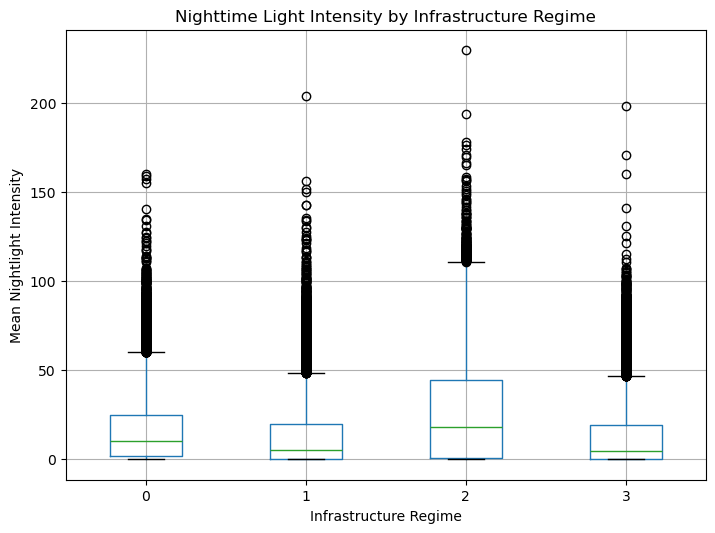

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

gdf.boxplot(
    column="nightlight_mean",
    by="regime_2D_full",
    ax=ax
)

ax.set_title("Nighttime Light Intensity by Infrastructure Regime")
ax.set_xlabel("Infrastructure Regime")
ax.set_ylabel("Mean Nightlight Intensity")

plt.suptitle("")

plt.show()

The comparison reveals clear differences in nighttime luminosity across mobility infrastructure regimes.

Regimes characterized by higher visitation intensity and stronger mobility stability patterns systematically exhibit higher levels of nighttime light intensity, indicating stronger economic activity.

Conversely, regimes associated with weak or unstable visitation patterns tend to correspond to areas with very low nighttime luminosity, reflecting limited economic infrastructure.

These results provide external validation that the Market Infrastructure Index captures meaningful spatial variation in the infrastructural conditions that support economic activity.

# 8 Multiscale Infrastructure Reconstruction

## 8.1 Motivation for Downscaling

Although census tracts provide a useful administrative unit for national analysis, they often mask substantial spatial heterogeneity within their boundaries.

In large metropolitan regions, individual census tracts may contain multiple urban environments with very different levels of accessibility, mobility intensity, and economic activity.

As a result, tract-level indicators may obscure fine-scale variations in the infrastructural conditions that support market participation.

To explore this hidden spatial structure, we implement a mass-preserving spatial downscaling procedure that reconstructs a continuous infrastructure surface within census tracts while preserving the aggregate index values originally observed at the tract level.

This approach allows us to examine how mobility-based market infrastructure varies at a finer spatial scale and to identify intra-tract fragmentation patterns that are not observable in aggregated tract-level data.

## 8.2 Study Area: São Paulo Metropolitan Region

To illustrate the multiscale structure of mobility infrastructure, we apply the downscaling procedure to the São Paulo metropolitan region.

São Paulo represents one of the largest and most economically dynamic urban systems in the Southern Hemisphere. The region contains a dense and heterogeneous urban landscape with strong contrasts in mobility infrastructure across neighborhoods.

This makes it an ideal setting for examining how mobility-based market infrastructure varies within census tracts and how aggregated tract-level measures may conceal important intra-urban spatial variation.

The downscaling analysis therefore focuses on reconstructing a high-resolution infrastructure surface for the São Paulo metropolitan region.

## 8.3 Mass-Preserving Spatial Downscaling

The downscaling procedure reconstructs a continuous infrastructure surface by redistributing tract-level index values across a fine spatial grid while preserving the aggregate values observed for each census tract.

This approach ensures that the reconstructed surface remains consistent with the original tract-level data while revealing spatial heterogeneity within administrative boundaries.

The resulting infrastructure surface therefore provides a high-resolution representation of the spatial organization of mobility-based market infrastructure.

In [ ]:
# ============================================================
# 8.3 Mass-Preserving Spatial Downscaling
# ============================================================

import geopandas as gpd
import numpy as np
from shapely.geometry import box

# ------------------------------------------------------------
# Step 1 — Load national regime dataset
# ------------------------------------------------------------

REGIME_PATH = "/ocean/projects/cis260037p/shared/data/regimes_shape/X8b_national_regime.gpkg"

gdf = gpd.read_file(REGIME_PATH)

print("National tracts loaded:", len(gdf))
print("CRS:", gdf.crs)

# ------------------------------------------------------------
# Step 2 — Convert CRS to geographic (needed for grid creation)
# ------------------------------------------------------------

gdf = gdf.to_crs(epsg=4326)

# ------------------------------------------------------------
# Step 3 — Select São Paulo metropolitan region
# ------------------------------------------------------------

print("\nSelecting São Paulo region...")

sp = gdf.cx[-47.2:-45.8, -24.2:-22.8]

print("Tracts in São Paulo region:", len(sp))

# ------------------------------------------------------------
# Step 4 — Compute bounding box
# ------------------------------------------------------------

xmin, ymin, xmax, ymax = sp.total_bounds

print("\nBounding box:")
print(xmin, ymin, xmax, ymax)

# ------------------------------------------------------------
# Step 5 — Create high-resolution grid (~100m)
# ------------------------------------------------------------

grid_size = 0.001   # ≈ 100 meters

cols = np.arange(xmin, xmax, grid_size)
rows = np.arange(ymin, ymax, grid_size)

print("\nGrid columns:", len(cols))
print("Grid rows:", len(rows))

polygons = []

for x in cols:
    for y in rows:
        polygons.append(
            box(
                x,
                y,
                x + grid_size,
                y + grid_size
            )
        )

grid = gpd.GeoDataFrame(
    geometry=polygons,
    crs="EPSG:4326"
)

print("\nTotal grid cells:", len(grid))

# ------------------------------------------------------------
# Step 6 — Spatial join with census tracts
# ------------------------------------------------------------

print("\nAssigning infrastructure regimes to grid cells...")

grid = gpd.sjoin(
    grid,
    sp[["regime_2D_full", "geometry"]],
    how="left",
    predicate="intersects"
)

print("Grid with regimes assigned:", len(grid))

# ------------------------------------------------------------
# Step 7 — Basic diagnostics
# ------------------------------------------------------------

print("\nGrid regime distribution:")

print(
    grid["regime_2D_full"]
    .value_counts()
)

National tracts loaded: 472780
CRS: EPSG:5880

Selecting São Paulo region...
Tracts in São Paulo region: 61548

Bounding box:
-47.35736099999996 -24.27246879999994 -45.66622729999995 -22.734601099999956

Grid columns: 1692
Grid rows: 1538

Total grid cells: 2602296

Assigning infrastructure regimes to grid cells...
Grid with regimes assigned: 3262818

Grid regime distribution:
regime_2D_full
0.0    696812
1.0    630058
2.0    609166
3.0    590443
Name: count, dtype: int64


## 8.4 Reconstructed Infrastructure Surface

The mass-preserving downscaling procedure produces a high-resolution representation of mobility-based market infrastructure within the São Paulo region.

Rather than assigning a single value to each census tract, the downscaling algorithm redistributes infrastructure intensity across a fine spatial grid while preserving the aggregate tract-level values. This reconstruction reveals spatial heterogeneity that is not observable at the tract level.

The resulting infrastructure surface highlights clusters of high-intensity mobility infrastructure embedded within broader urban environments and exposes localized variation within census tracts that would otherwise remain hidden.

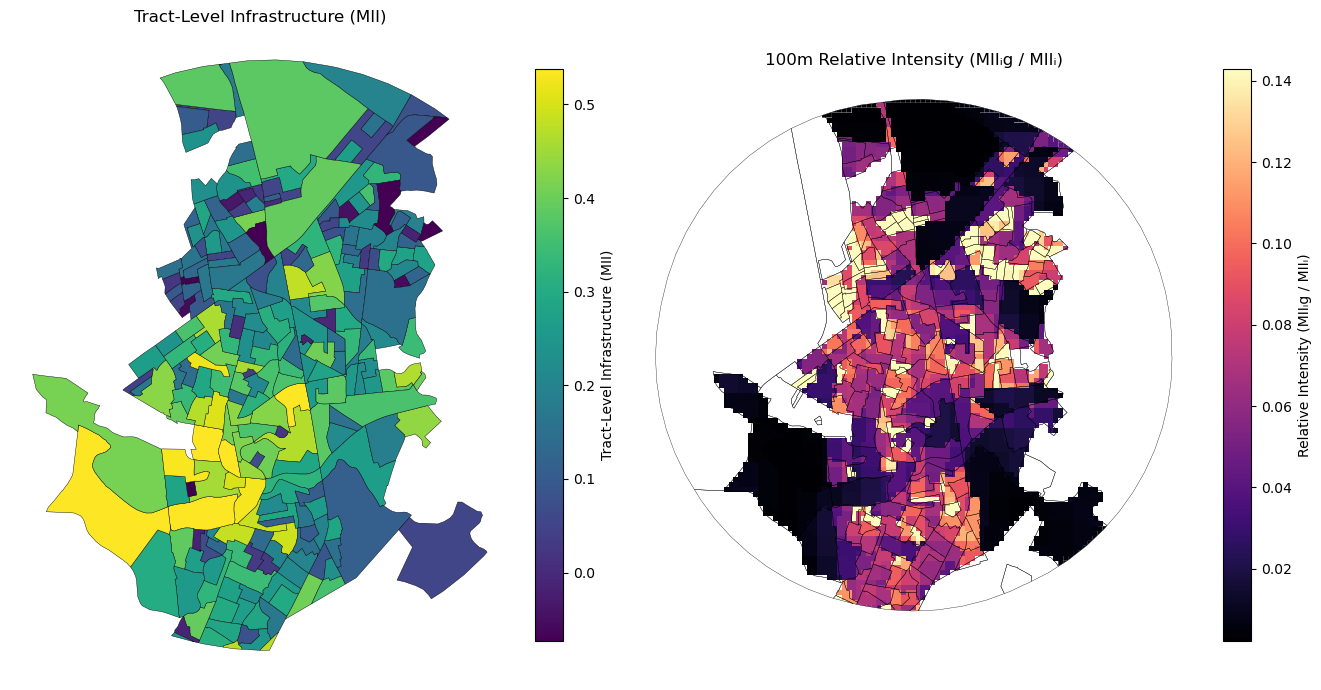

In [ ]:
# ============================================================
# 8.4 Reconstructed Infrastructure Surface (with colorbars)
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable

# ------------------------------------------------------------
# Prepare datasets
# ------------------------------------------------------------

gdf_grid = gdf_grid.copy()
gdf_tracts = gdf_tracts.copy()

# ------------------------------------------------------------
# Compute relative intensity
# ------------------------------------------------------------

gdf_grid["relative_intensity"] = (
    gdf_grid["mii_100m"] / gdf_grid["mii_tract"]
)

gdf_grid = gdf_grid.replace([np.inf, -np.inf], np.nan)
gdf_grid = gdf_grid.dropna(subset=["relative_intensity"]).copy()

# ------------------------------------------------------------
# Robust scaling
# ------------------------------------------------------------

low = np.nanpercentile(gdf_grid["relative_intensity"], 5)
high = np.nanpercentile(gdf_grid["relative_intensity"], 95)

vcenter = 1.0

if low < vcenter < high:
    norm_right = TwoSlopeNorm(vmin=low, vcenter=vcenter, vmax=high)
else:
    norm_right = Normalize(vmin=low, vmax=high)

vals_left = gdf_tracts["mii_tract"].astype(float)
vmin_left = np.nanpercentile(vals_left, 2)
vmax_left = np.nanpercentile(vals_left, 98)
norm_left = Normalize(vmin=vmin_left, vmax=vmax_left)

# ------------------------------------------------------------
# Colormaps
# ------------------------------------------------------------

cmap_left = plt.cm.viridis
cmap_right = plt.cm.magma.copy()
cmap_right.set_bad("black")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14,7))

# LEFT PANEL
gdf_tracts.plot(
    column="mii_tract",
    cmap=cmap_left,
    norm=norm_left,
    linewidth=0.3,
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Tract-Level Infrastructure (MII)")
axes[0].axis("off")

# RIGHT PANEL
gdf_grid.plot(
    column="relative_intensity",
    cmap=cmap_right,
    norm=norm_right,
    linewidth=0,
    ax=axes[1]
)

gdf_tracts.boundary.plot(
    ax=axes[1],
    linewidth=0.25,
    edgecolor="black"
)

axes[1].set_title("100m Relative Intensity (MIIᵢg / MIIᵢ)")
axes[1].axis("off")

# ------------------------------------------------------------
# Colorbars
# ------------------------------------------------------------

sm_left = ScalarMappable(norm=norm_left, cmap=cmap_left)
sm_left.set_array([])

sm_right = ScalarMappable(norm=norm_right, cmap=cmap_right)
sm_right.set_array([])

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

cbar_left.set_label("Tract-Level Infrastructure (MII)")

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

cbar_right.set_label("Relative Intensity (MIIᵢg / MIIᵢ)")

plt.tight_layout()
plt.show()

The reconstructed infrastructure surface reveals substantial spatial heterogeneity within census tracts.

While the tract-level representation assigns a single infrastructure value to each administrative unit, the downscaled surface exposes fine-scale variation in mobility-based infrastructure intensity across the urban landscape.

High-intensity clusters emerge along major transportation corridors and in dense commercial zones, while adjacent areas exhibit substantially lower relative intensities. These localized variations demonstrate that census tract boundaries often mask internal spatial differentiation in the infrastructural conditions that support mobility and economic interaction.

By redistributing infrastructure intensity across a fine spatial grid while preserving tract-level totals, the mass-preserving downscaling procedure makes previously hidden intra-tract patterns of market infrastructure observable.

## 8.5 Intra-Tract Fragmentation

The downscaled infrastructure surface reveals that many census tracts contain substantial internal heterogeneity in mobility-based market infrastructure.

Rather than representing homogeneous spatial units, census tracts frequently contain multiple localized infrastructure environments that differ significantly in the intensity of visitation.

This fragmentation is particularly visible in large metropolitan areas, where commercial districts, transportation hubs, residential zones, and peripheral areas coexist within the same administrative tract.

The downscaling results demonstrate that tract-level infrastructure measures should be interpreted as aggregated representations of underlying spatial processes rather than as homogeneous spatial environments.

Recognizing this internal heterogeneity is critical for understanding how mobility infrastructure shapes local economic opportunities and market participation across urban space.

# 9 Discussion

This study demonstrates that mobility intensity alone is insufficient to explain spatial variation in local economic activity. Instead, the spatial structure of mobility interactions reveals a latent infrastructural layer that conditions the feasibility of sustained market participation.

By extracting the dominant covariance structure among mobility indicators, the Market Infrastructure Index (MII) captures this latent infrastructure and reveals substantial spatial heterogeneity across the national territory. Locations exhibiting similar mobility volumes frequently belong to distinct infrastructural regimes, indicating that the organization of visitation patterns plays a critical role in shaping economic environments.

The analysis of nighttime luminosity further provides external validation for these regimes. Areas with stronger mobility infrastructure systematically correspond to higher nighttime light intensity, suggesting that mobility infrastructure is closely associated with the spatial organization of economic activity.

The multiscale reconstruction experiment in the São Paulo region further reveals that census tracts often conceal significant internal heterogeneity in infrastructure conditions. The downscaled surface shows that infrastructure intensity varies continuously across space and frequently exhibits strong fragmentation within administrative boundaries.

These findings highlight the importance of modeling spatial processes across multiple scales and demonstrate that mobility-based indicators can provide valuable insights into the spatial foundations of market systems.

# 10 Conclusion

This study introduced a spatial framework to identify and reconstruct mobility-based market infrastructure using large-scale mobility data.

By deriving the Market Infrastructure Index (MII) from the covariance structure of visitation behavior, the analysis reveals that mobility infrastructure forms a spatially heterogeneous and multiscalar field rather than a uniform geography of movement.

The identification of infrastructure regimes demonstrates that locations with similar levels of mobility intensity may exhibit fundamentally different structural conditions supporting economic interaction. External validation using nighttime luminosity confirms that these regimes correspond to distinct economic environments.

The multiscale downscaling experiment further shows that aggregated administrative units frequently conceal substantial internal variation in mobility-based infrastructure, underscoring the importance of spatially explicit modeling approaches.

Together, these results contribute a reproducible Spatial AI framework for recovering latent infrastructural structures from mobility data and for reconstructing fine-grained spatial variation while preserving aggregate consistency. This approach opens new possibilities for studying the spatial foundations of economic systems and for identifying the infrastructural conditions that enable markets to emerge and persist across urban space.